# Exploratory Data Analysis of Merged Lung Sounds Dataset
This notebook provides an exploratory data analysis (EDA) of the merged `manifest.csv`.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('merged_dataset/manifest.csv')
df['duration'] = df['end_s'] - df['start_s']
df.head()

,audio_filename,start_s,end_s,label,label_fine,source,location,duration
0,icbhi_101_1b1_Al_sc_Meditron.wav,0.036,0.579,normal,normal,icbhi,anterior_left,0.543
1,icbhi_101_1b1_Al_sc_Meditron.wav,0.579,2.450,normal,normal,icbhi,anterior_left,1.871
2,icbhi_101_1b1_Al_sc_Meditron.wav,2.450,3.893,normal,normal,icbhi,anterior_left,1.443
3,icbhi_101_1b1_Al_sc_Meditron.wav,3.893,5.793,normal,normal,icbhi,anterior_left,1.900
4,icbhi_101_1b1_Al_sc_Meditron.wav,5.793,7.521,normal,normal,icbhi,anterior_left,1.728


## 1. Class Distribution Overall
Let's see the balance between Normal, Crackle, and Wheeze.

C:\Users\crick\AppData\Local\Temp\ipykernel_14124\3716105493.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='Set2')


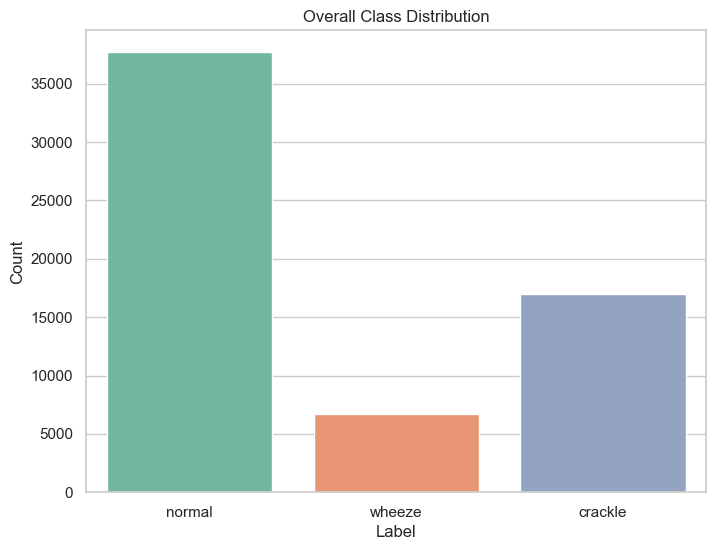

In [8]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='label', palette='Set2')
plt.title("Overall Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

## 2. Class Distribution by Source Dataset
How does each dataset contribute to the labels?

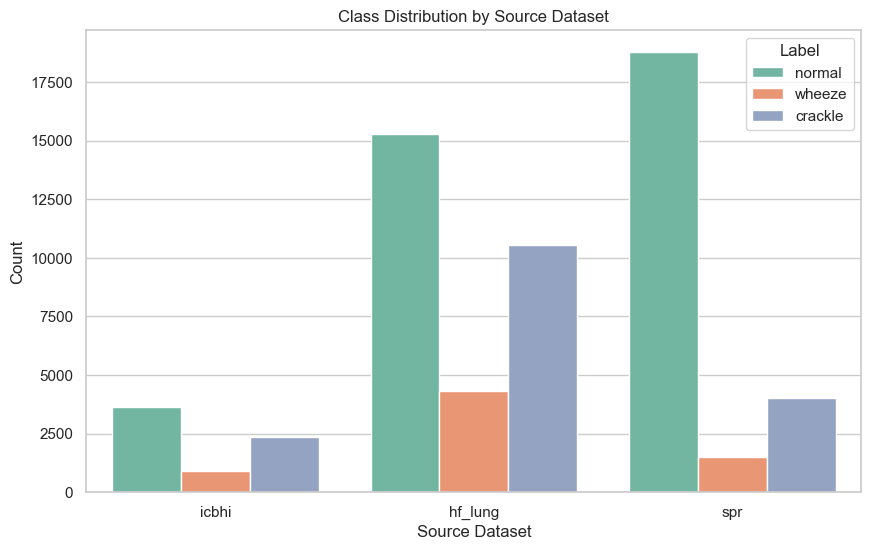

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='source', hue='label', palette='Set2')
plt.title("Class Distribution by Source Dataset")
plt.xlabel("Source Dataset")
plt.ylabel("Count")
plt.legend(title='Label')
plt.show()

## 3. Cycle Durations
Let's look at how long the respiratory cycles are.

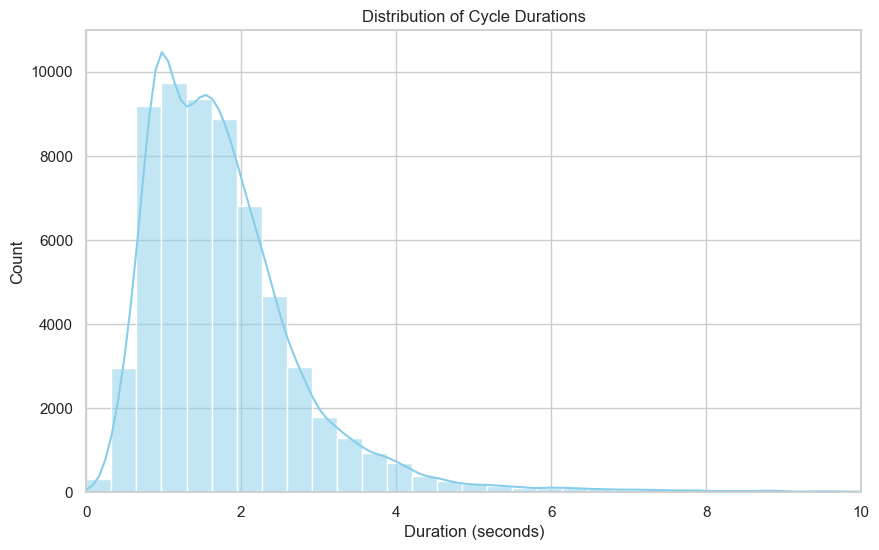

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='duration', bins=50, kde=True, color='skyblue')
plt.title("Distribution of Cycle Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.xlim(0, 10)
plt.show()

## 4. Cycle Duration by Label
Are abnormal sounds longer or shorter?

C:\Users\crick\AppData\Local\Temp\ipykernel_14124\2583075512.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='duration', palette='Set2', showfliers=False)


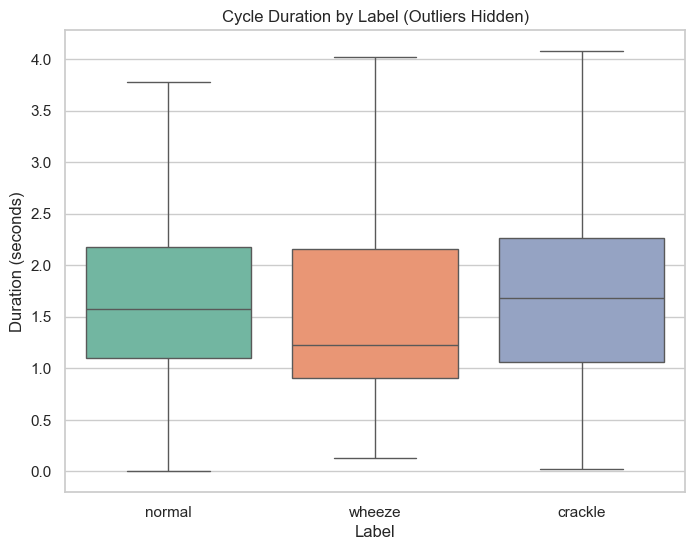

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='duration', palette='Set2', showfliers=False)
plt.title("Cycle Duration by Label (Outliers Hidden)")
plt.xlabel("Label")
plt.ylabel("Duration (seconds)")
plt.show()

## 5. Fine-Grained Label Breakdown
Looking at the more specific labels like fine vs coarse crackles.

C:\Users\crick\AppData\Local\Temp\ipykernel_14124\435405118.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label_fine', order=df['label_fine'].value_counts().index, palette='Spectral')


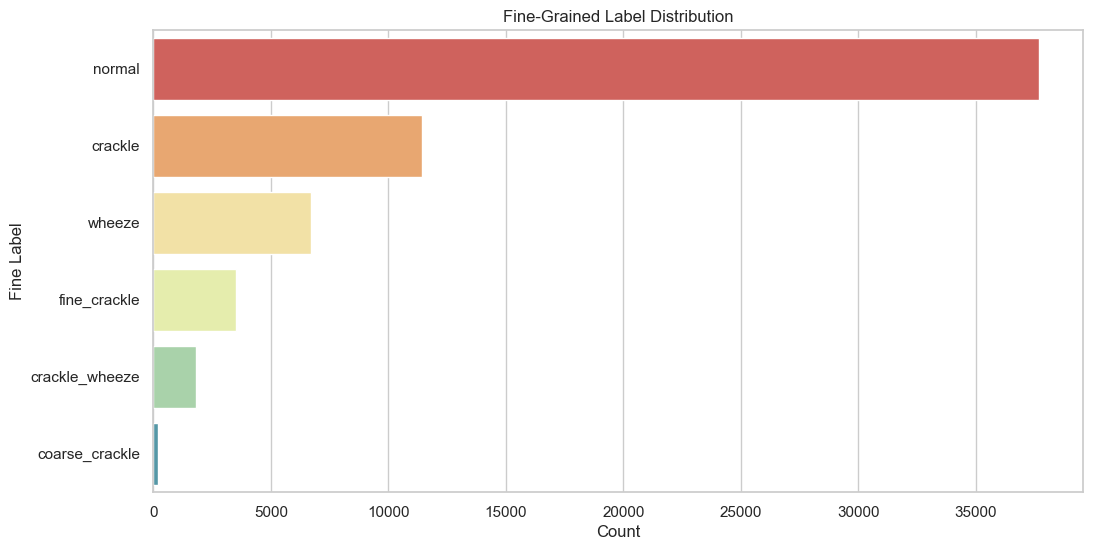

In [12]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='label_fine', order=df['label_fine'].value_counts().index, palette='Spectral')
plt.title("Fine-Grained Label Distribution")
plt.xlabel("Count")
plt.ylabel("Fine Label")
plt.show()